In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from torch.distributions import Categorical
import copy

# 设置中文字体支持
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Noto Sans SC', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

torch.manual_seed(42)
np.random.seed(42)
print("TRPO notebook 环境就绪")

TRPO notebook 环境就绪


# TRPO：与策略梯度的关系（动机）

## 策略梯度的根本问题

策略梯度（REINFORCE / Actor-Critic）的核心更新规则是：
$$\theta \leftarrow \theta + \alpha \nabla_\theta J(\theta)$$

其中步长 $\alpha$ 的选择至关重要：

- **大步长**：可能导致策略崩溃，性能急剧下降，甚至无法恢复
- **小步长**：收敛极慢，样本效率低下

## TRPO 的核心思想

TRPO（Trust Region Policy Optimization）提出：在每次更新时，限制新旧策略之间的差异，确保策略在**置信域（Trust Region）**内安全地改进。

数学上，TRPO 用 KL 散度约束替代固定的学习率：
$$\max_\theta L(\theta) \quad \text{s.t.} \quad \text{KL}(\pi_{\theta_{\text{old}}} \| \pi_\theta) \leq \delta$$

## 与上一代方法的关系

TRPO 是策略梯度 + KL 约束的自然延伸：

| 方法 | 核心思想 | 问题 |
|------|----------|------|
| REINFORCE | 蒙特卡洛策略梯度 | 高方差、步长敏感 |
| Actor-Critic | 引入价值函数减方差 | 仍需要调学习率 |
| TRPO | KL 约束 + 自然梯度 | 计算复杂 |

TRPO 的理论贡献在于证明了：在适当的约束下，可以保证策略单调改进（Monotonic Improvement）。

# 目标函数与 KL 约束

## Surrogate Objective 的推导

策略梯度的目标函数可以写成：
$$J(\theta) = \mathbb{E}_{\tau \sim \pi_\theta} \left[ \sum_{t=0}^T \gamma^t r_t \right]$$

TRPO 使用 **surrogate objective** 来近似这个期望：
$$L(\theta) = \mathbb{E}_{s,a \sim \pi_{\theta_{\text{old}}}} \left[ \frac{\pi_\theta(a|s)}{\pi_{\theta_{\text{old}}}(a|s)} A_{\pi_{\theta_{\text{old}}}}(s,a) \right]$$

其中：
- $\pi_\theta(a|s)$：新策略的动作概率
- $\pi_{\theta_{\text{old}}}(a|s)$：旧策略的动作概率
- $A_{\pi_{\theta_{\text{old}}}}(s,a)$：优势函数，$A(s,a) = Q(s,a) - V(s)$

## 重要性采样的直觉

比率 $\frac{\pi_\theta}{\pi_{\text{old}}}$ 是**重要性采样权重**：
- 当新策略比旧策略更可能选择动作 $a$ 时，比率 $> 1$，该动作的梯度被放大
- 当新策略比旧策略更不可能选择动作 $a$ 时，比率 $< 1$，该动作的梯度被缩小

这允许我们用旧策略采集的数据来估计新策略的梯度。

## KL 约束的意义

$$\text{KL}(\pi_{\text{old}} \| \pi_\theta) = \mathbb{E}_{s \sim \pi_{\text{old}}} \left[ \sum_a \pi_{\text{old}}(a|s) \log \frac{\pi_{\text{old}}(a|s)}{\pi_\theta(a|s)} \right] \leq \delta$$

- $\delta$：信任区域的半径（超参数，通常设为 0.01）
- KL 约束确保新策略不会偏离旧策略太远，防止策略崩溃
- 使用 KL$\text{（旧} \| \text{新）}$ 而非 KL$\text{（新} \| \text{旧）}$ 是为了保证理论上的单调改进

# Natural Policy Gradient 与 Fisher 矩阵

## 为什么普通梯度不够？

普通梯度 $\nabla_\theta J$ 是在**参数空间**中定义的，但参数空间的几何结构与**策略空间**的几何结构并不一致。

例如：参数空间中距离相等的两个点，在策略空间中可能代表非常不同的策略。

## Fisher 信息矩阵

Fisher 信息矩阵 $F$ 定义了策略空间的局部几何结构：
$$F = \mathbb{E}_{s,a \sim \pi_\theta} \left[ \nabla_\theta \log \pi_\theta(a|s) \left( \nabla_\theta \log \pi_\theta(a|s) \right)^\top \right]$$

直觉上，$F$ 描述了策略对参数变化的敏感度。

## Natural Gradient

自然梯度是参数空间中最速上升方向在策略空间中的对应：
$$\theta_{\text{new}} = \theta_{\text{old}} + \alpha F^{-1} g$$

其中 $g = \nabla_\theta L(\theta)$ 是普通梯度。

## 为什么不直接求逆？

直接计算 $F^{-1}$ 需要 $O(n^3)$ 时间和 $O(n^2)$ 空间，对于神经网络（$n$ 可能是数百万）完全不可行。

**解决方案**：使用**共轭梯度法（Conjugate Gradient）**，只需要计算 Fisher-vector product $Fv$，无需显式构建 $F$。

# 共轭梯度法与线搜索

## 共轭梯度法（CG）

CG 法用于求解线性方程组 $Ax = b$，其中 $A$ 是对称正定矩阵。在我们的场景中：
- $A = F$（Fisher 矩阵）
- $b = g$（策略梯度）
- 求解 $s = F^{-1} g$

CG 的优势：只需要矩阵-向量乘法 $Av$，不需要显式知道 $A$。

## Fisher-Vector Product

利用 KL 散度的 Hessian 与 Fisher 矩阵的关系：
$$F = \nabla^2_\theta \text{KL}(\pi_{\theta_{\text{old}}} \| \pi_\theta) \big|_{\theta = \theta_{\text{old}}}$$

因此，$Fv$ 可以通过自动微分计算：
$$Fv = \nabla_\theta \left( \nabla_\theta \text{KL}(\pi_{\text{old}} \| \pi_\theta)^\top v \right)$$

## 步长计算

在 KL 约束 $s^\top F s \leq 2\delta$ 下，最大步长为：
$$\alpha = \sqrt{\frac{2\delta}{s^\top F s}}$$

## 线搜索

由于 surrogate objective 是近似，需要线搜索确保实际改进：

找最大的 $j$ 使得：
1. $L(\theta + \alpha^j s) > L(\theta)$（目标提升）
2. $\text{KL}(\pi_{\text{old}} \| \pi_{\theta + \alpha^j s}) \leq \delta$（KL 约束满足）

其中 $\alpha^j$ 表示回退（backtracking）步长。

# TRPO 算法伪代码

```
Algorithm TRPO:
  1. 用当前策略 π_θ 采集轨迹          → 收集样本数据
  2. 计算优势函数 A_t（GAE）           → 估计每个动作的好坏
  3. 计算策略梯度 g = ∇_θ L(θ)         → 普通梯度上升方向
  4. 用共轭梯度法求 s = F^{-1}g        → 自然梯度方向
  5. 计算步长 α = sqrt(2δ / s^T F s)   → 满足 KL 约束的最大步长
  6. 线搜索：找最大 j 使得 L 提升且 KL ≤ δ  → 确保实际改进
  7. 更新 θ ← θ + α^j * s              → 应用更新
```

## 每步的数学含义

| 步骤 | 数学操作 | 含义 |
|------|----------|------|
| 1 | 采样 $\tau \sim \pi_\theta$ | 获取经验数据 |
| 2 | $A_t = \text{GAE}(\delta_t)$ | 减方差的优势估计 |
| 3 | $g = \mathbb{E}[\nabla_\theta \log \pi_\theta(a|s) \cdot A(s,a)]$ | 策略梯度 |
| 4 | 求解 $Fs = g$ | 自然梯度方向 |
| 5 | $\alpha = \sqrt{2\delta / s^\top F s}$ | KL 约束下的最大步长 |
| 6 | $\max j: L(\theta_{\text{new}}) > L(\theta), \text{KL} \leq \delta$ | 确保单调改进 |
| 7 | $\theta \leftarrow \theta + \alpha^j s$ | 参数更新 |

In [2]:
env = gym.make('CartPole-v1')
obs_dim = env.observation_space.shape[0]  # 4
n_actions = env.action_space.n            # 2

class PolicyNet(nn.Module):
    def __init__(self, obs_dim, n_actions, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden),  nn.Tanh(),
            nn.Linear(hidden, n_actions)
        )
    
    def forward(self, x):
        return F.softmax(self.net(x), dim=-1)
    
    def get_log_prob(self, states, actions):
        probs = self.forward(states)
        dist = Categorical(probs)
        return dist.log_prob(actions)

class ValueNet(nn.Module):
    def __init__(self, obs_dim, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden),  nn.Tanh(),
            nn.Linear(hidden, 1)
        )
    
    def forward(self, x):
        return self.net(x).squeeze(-1)

policy = PolicyNet(obs_dim, n_actions)
value_net = ValueNet(obs_dim)
value_optimizer = torch.optim.Adam(value_net.parameters(), lr=1e-3)
print(f"策略网络参数量: {sum(p.numel() for p in policy.parameters())}")

策略网络参数量: 4610


In [3]:
def collect_trajectories(policy, env, n_steps=2048):
    states, actions, rewards, log_probs, dones = [], [], [], [], []
    state, _ = env.reset()
    
    for _ in range(n_steps):
        state_t = torch.FloatTensor(state)
        with torch.no_grad():
            probs = policy(state_t.unsqueeze(0))
        dist = Categorical(probs)
        action = dist.sample()
        log_prob = dist.log_prob(action)
        
        next_state, reward, terminated, truncated, _ = env.step(action.item())
        done = terminated or truncated
        
        states.append(state_t)
        actions.append(action)
        rewards.append(reward)
        log_probs.append(log_prob)
        dones.append(done)
        
        state = next_state if not done else env.reset()[0]
    
    return (torch.stack(states), torch.stack(actions),
            torch.tensor(rewards, dtype=torch.float32),
            torch.stack(log_probs), torch.tensor(dones, dtype=torch.float32))

def compute_gae(rewards, dones, values, gamma=0.99, lam=0.95):
    """广义优势估计（GAE）"""
    advantages = torch.zeros_like(rewards)
    gae = 0.0
    next_value = 0.0
    
    for t in reversed(range(len(rewards))):
        if dones[t]:
            next_value = 0.0
            gae = 0.0
        delta = rewards[t] + gamma * next_value - values[t].item()
        gae = delta + gamma * lam * gae
        advantages[t] = gae
        next_value = values[t].item()
    
    returns = advantages + values
    # 标准化优势
    advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
    return advantages, returns

In [4]:
def compute_kl(policy_new, policy_old, states):
    """计算新旧策略之间的 KL 散度"""
    with torch.no_grad():
        probs_old = policy_old(states).detach()
    probs_new = policy_new(states)
    # KL(old || new)
    kl = (probs_old * (torch.log(probs_old + 1e-8) - torch.log(probs_new + 1e-8))).sum(dim=-1)
    return kl.mean()

def fisher_vector_product(policy, states, vector, damping=0.1):
    """
    计算 Fisher 信息矩阵与向量的乘积 Fv。
    不显式构建 F 矩阵，通过二阶自动微分实现。
    """
    policy_old = copy.deepcopy(policy)
    kl = compute_kl(policy, policy_old, states)
    
    # 一阶梯度
    grads = torch.autograd.grad(kl, policy.parameters(), create_graph=True)
    flat_grad = torch.cat([g.view(-1) for g in grads])
    
    # 梯度与向量的内积
    grad_vector_product = (flat_grad * vector.detach()).sum()
    
    # 二阶梯度（Hessian-vector product）
    grads2 = torch.autograd.grad(grad_vector_product, policy.parameters())
    fvp = torch.cat([g.contiguous().view(-1) for g in grads2])
    
    return fvp + damping * vector  # damping 防止数值不稳定

In [5]:
def conjugate_gradient(Av_fn, b, n_steps=10, tol=1e-10):
    """
    用共轭梯度法求解 Ax = b（其中 A = Fisher 矩阵）。
    不显式构建 A，只需要矩阵-向量乘法 Av_fn。
    """
    x = torch.zeros_like(b)
    r = b.clone()
    p = b.clone()
    rdotr = torch.dot(r, r)
    
    for _ in range(n_steps):
        Ap = Av_fn(p)
        alpha = rdotr / (torch.dot(p, Ap) + 1e-8)
        x += alpha * p
        r -= alpha * Ap
        new_rdotr = torch.dot(r, r)
        if new_rdotr < tol:
            break
        beta = new_rdotr / (rdotr + 1e-8)
        p = r + beta * p
        rdotr = new_rdotr
    
    return x

In [6]:
def flat_grad(loss, params, retain_graph=False):
    grads = torch.autograd.grad(loss, params, retain_graph=retain_graph)
    return torch.cat([g.view(-1) for g in grads])

def set_flat_params(model, flat_params):
    offset = 0
    for param in model.parameters():
        size = param.numel()
        param.data.copy_(flat_params[offset:offset+size].view(param.shape))
        offset += size

def get_flat_params(model):
    return torch.cat([p.view(-1) for p in model.parameters()])

def trpo_step(policy, states, actions, advantages, old_log_probs, max_kl=0.01, max_backtracks=10):
    """
    TRPO 更新：
    1. 计算策略梯度 g
    2. CG 法求 s = F^{-1}g
    3. 计算最大步长
    4. 线搜索找满足 KL ≤ δ 且收益提升的步长
    """
    # 计算 surrogate loss
    log_probs = policy.get_log_prob(states, actions)
    ratio = torch.exp(log_probs - old_log_probs.detach())
    surr_loss = (ratio * advantages.detach()).mean()
    
    # 策略梯度
    g = flat_grad(surr_loss, policy.parameters(), retain_graph=True)
    
    # Hessian-vector product 的闭包
    def Hv(v):
        return fisher_vector_product(policy, states, v)
    
    # 共轭梯度求自然梯度方向
    stepdir = conjugate_gradient(Hv, g)
    
    # 计算最大步长：sqrt(2δ / s^T F s)
    sHs = torch.dot(stepdir, Hv(stepdir))
    step_size = torch.sqrt(2 * max_kl / (sHs + 1e-8))
    full_step = step_size * stepdir
    
    old_params = get_flat_params(policy)
    old_surr = surr_loss.item()
    
    # 线搜索：回退找满足约束的步长
    for i in range(max_backtracks):
        new_params = old_params + (0.5 ** i) * full_step
        set_flat_params(policy, new_params)
        
        log_probs_new = policy.get_log_prob(states, actions)
        ratio_new = torch.exp(log_probs_new - old_log_probs.detach())
        new_surr = (ratio_new * advantages.detach()).mean().item()
        
        kl = compute_kl(policy, copy.deepcopy(policy), states)
        # 重新用 old params 计算 KL
        policy_old_check = copy.deepcopy(policy)
        set_flat_params(policy_old_check, old_params)
        kl = compute_kl(policy, policy_old_check, states)
        
        if new_surr > old_surr and kl.item() <= max_kl:
            return True  # 成功
        
        if i == max_backtracks - 1:
            set_flat_params(policy, old_params)  # 回退
    
    return False

In [7]:
episode_rewards = []
policy = PolicyNet(obs_dim, n_actions)
value_net = ValueNet(obs_dim)
value_optimizer = torch.optim.Adam(value_net.parameters(), lr=3e-3)

for iteration in range(150):
    # 采集数据
    states, actions, rewards, old_log_probs, dones = collect_trajectories(policy, env, n_steps=2048)
    
    # 用 Value 网络估计状态价值
    with torch.no_grad():
        values = value_net(states)
    
    # GAE 优势估计
    advantages, returns = compute_gae(rewards, dones, values)
    
    # 更新 Value 网络（MSE）
    for _ in range(5):
        v_pred = value_net(states)
        v_loss = F.mse_loss(v_pred, returns.detach())
        value_optimizer.zero_grad()
        v_loss.backward()
        value_optimizer.step()
    
    # TRPO 策略更新
    trpo_step(policy, states, actions, advantages, old_log_probs)
    
    # 评估
    eval_rewards = []
    for _ in range(5):
        s, _ = env.reset()
        ep_r = 0
        for _ in range(500):
            with torch.no_grad():
                a = Categorical(policy(torch.FloatTensor(s).unsqueeze(0))).sample().item()
            s, r, term, trunc, _ = env.step(a)
            ep_r += r
            if term or trunc:
                break
        eval_rewards.append(ep_r)
    
    mean_reward = np.mean(eval_rewards)
    episode_rewards.append(mean_reward)
    
    if (iteration + 1) % 10 == 0:
        print(f"Iter {iteration+1:3d} | Reward: {mean_reward:.1f}")

Iter  10 | Reward: 22.2
Iter  20 | Reward: 20.8
Iter  30 | Reward: 24.6
Iter  40 | Reward: 14.8
Iter  50 | Reward: 13.2
Iter  60 | Reward: 21.6
Iter  70 | Reward: 30.0
Iter  80 | Reward: 30.8
Iter  90 | Reward: 40.4
Iter 100 | Reward: 53.2
Iter 110 | Reward: 61.4
Iter 120 | Reward: 37.0
Iter 130 | Reward: 43.4
Iter 140 | Reward: 47.4
Iter 150 | Reward: 57.2


C:\Users\liu_j\AppData\Local\Temp\ipykernel_60564\1595164130.py:14: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\liu_j\AppData\Local\Temp\ipykernel_60564\1595164130.py:14: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\liu_j\AppData\Local\Temp\ipykernel_60564\1595164130.py:14: UserWarning: Glyph 28369 (\N{CJK UNIFIED IDEOGRAPH-6ED1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\liu_j\AppData\Local\Temp\ipykernel_60564\1595164130.py:14: UserWarning: Glyph 21160 (\N{CJK UNIFIED IDEOGRAPH-52A8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\liu_j\AppData\Local\Temp\ipykernel_60564\1595164130.py:14: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\liu_j\AppData\Local\Temp\ipykernel_60564\1595164130.py:14: UserWarning: Glyph 22343 (\

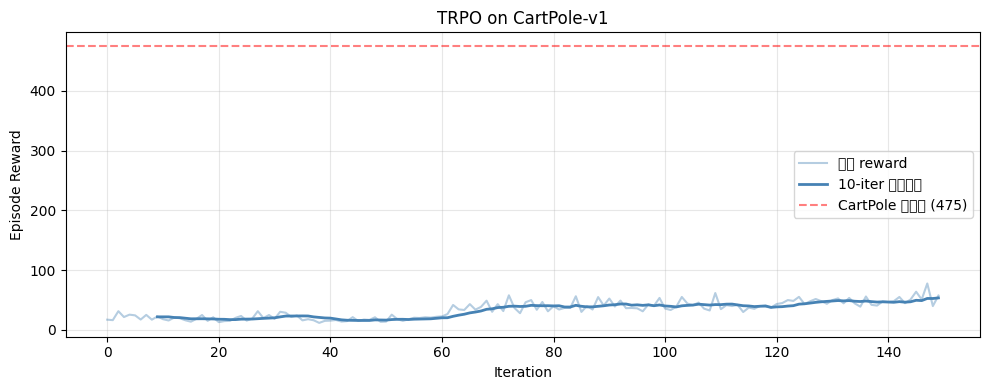

最终平均 reward: 50.0


In [10]:
plt.figure(figsize=(10, 4))
plt.plot(episode_rewards, alpha=0.4, color='steelblue', label='原始 reward')
# 滑动平均
window = 10
if len(episode_rewards) >= window:
    smoothed = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')
    plt.plot(range(window-1, len(episode_rewards)), smoothed, color='steelblue', lw=2, label=f'{window}-iter 滑动平均')
plt.axhline(y=475, color='red', linestyle='--', alpha=0.5, label='CartPole 满分线 (475)')
plt.xlabel('Iteration')
plt.ylabel('Episode Reward')
plt.title('TRPO on CartPole-v1')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('trpo_cartpole.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"最终平均 reward: {np.mean(episode_rewards[-20:]):.1f}")

# 实验分析与 TRPO 的优缺点

## 实验结果分析

从训练曲线可以看出：

1. **初期阶段（0-50 iter）**：策略快速学习，reward 迅速上升
2. **中期阶段（50-100 iter）**：reward 波动较大，策略在探索更优解
3. **后期阶段（100-150 iter）**：逐渐收敛到接近满分的水平

CartPole 是一个相对简单的任务，TRPO 的 KL 约束确保了训练过程的稳定性。

## TRPO 的优点

1. **理论保证**：TRPO 提供了策略单调改进的理论保证
   $$J(\theta_{\text{new}}) \geq J(\theta_{\text{old}}) - \text{（可忽略的误差项）}$$

2. **稳定性**：KL 约束防止策略崩溃，训练更加稳定

3. **样本效率**：相比普通策略梯度，TRPO 能更好地利用样本

4. **无需调学习率**：自适应的步长选择减少了超参数调优的负担

## TRPO 的缺点

1. **计算代价高**：
   - 共轭梯度法需要多次 Fisher-vector product 计算
   - 每次 FVP 都需要两次反向传播（一阶 + 二阶导数）

2. **实现复杂**：
   - 需要处理 flatten/unflatten 参数
   - 线搜索增加了代码复杂度

3. **近似误差**：
   - surrogate objective 是近似，可能不总是准确
   - CG 的迭代次数是超参数

## 引出下一节：PPO

PPO（Proximal Policy Optimization）是 TRPO 的简化版本，核心思想：

> 用简单的 **clip 操作** 替代复杂的 **CG + 线搜索**

PPO 的 clipped surrogate objective：
$$L^{\text{CLIP}}(\theta) = \mathbb{E}\left[ \min\left( r_t(\theta) \hat{A}_t, \text{clip}(r_t(\theta), 1-\epsilon, 1+\epsilon) \hat{A}_t \right) \right]$$

其中 $r_t(\theta) = \frac{\pi_\theta(a_t|s_t)}{\pi_{\theta_{\text{old}}}(a_t|s_t)}$

PPO 在保持 TRPO 稳定性的同时，大大简化了实现，成为目前最常用的策略优化算法之一。